# TRS partial transpose boundary operator extraction
Created 04/06/2026

Objectives:
* Extract the boundary operators from [these states](../../save_states/z4_z2_trs_cluster_chain_100_site_dmrg.ipynb).
    * Just work on fixed point states for now.
* Construct all possible partial transpose cost functions, and optimize over them simultaneuosly. Will hopefully reduce degeneracy.

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [169]:
from functools import reduce
from itertools import combinations, combinations_with_replacement

from tqdm import tqdm

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import unitary_group

In [5]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [7]:
DATA_DIR = r"../../data/4_2_trs_cluster_chain_100_unit_cells"

In [80]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    if (local_file_name[-3:] == '.h5') and ((local_file_name[:2] == '0_') or (local_file_name[:4] == '100_')):
        f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data.append(data)

In [81]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [82]:
loaded_data

[{'energy': -199.99999999999693,
  'paramters': {'interpolation': 0.0},
  'wavefunction': <tenpy.networks.mps.MPS at 0x7f7a9eb326d0>},
 {'energy': -197.99999999999957,
  'paramters': {'interpolation': 1.0},
  'wavefunction': <tenpy.networks.mps.MPS at 0x7f7a9e93d090>}]

In [83]:
psi_0 = get_quimb_mps(loaded_data[0]['wavefunction'])
psi_1 = get_quimb_mps(loaded_data[1]['wavefunction'])

# Definitions

In [12]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [13]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [14]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [15]:
np_X4 = np.array(
    [
        [0,0,0,1],
        [1,0,0,0],
        [0,1,0,0],
        [0,0,1,0],
    ]
)

## Function definitions

In [16]:
def svd_update(environment_matrix, first_boundary_guess,
               first_left_inds, second_left_inds):
    """
    Should comment this.
    """

    first_env_matrix = (first_boundary_guess & environment_matrix) ^ ...

    svd = first_env_matrix.split(
        left_inds=second_left_inds,
        absorb=None,
        bond_ind='s'
    )

    first_score = np.sum(svd.tensors[1].data)
    first_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    first_unitary = first_unitary.conj()
    
    second_env_matrix = (first_unitary & environment_matrix) ^ ...

    svd = second_env_matrix.split(
        left_inds=first_left_inds,
        absorb=None,
        bond_ind='s'
    )

    second_score = np.sum(svd.tensors[1].data)
    second_unitary = (svd.tensors[0] & svd.tensors[2]) ^ ...
    second_unitary = second_unitary.conj()

    return (
        [first_unitary, second_unitary],
        [first_score, second_score]
    )

In [17]:
def iterated_svd_updates(environment_matrix, first_ket_inds,
                         second_ket_inds, first_bra_inds, num_iters):
    scores = list()

    # Hard code warning!
    rand_unitary = unitary_group.rvs(4)
    rand_unitary = np.reshape(rand_unitary, (2,2,2,2))

    boundary_guess = qtn.tensor_core.Tensor(
        rand_unitary,
        inds=first_ket_inds+first_bra_inds
    )

    for i in range(num_iters):
        current_out = svd_update(
            environment_matrix,
            boundary_guess,
            first_ket_inds,
            second_ket_inds
        )
        scores.extend(current_out[1])
        boundary_guess = current_out[0][1]


    return (current_out[0], scores)

In [18]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [19]:
def find_boundary_operators(psi, leftmost_symmetry_site,
    rightmost_symmetry_site, num_boundary_sites, num_iters):

    symmetry_sites = list(range(leftmost_symmetry_site, rightmost_symmetry_site+1))
    all_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    rho = psi.partial_trace_to_mpo(
        all_sites,
        rescale_sites=False
    )
    
    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
        inplace=True
    )
    
    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in symmetry_sites
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in symmetry_sites
    ]

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=False)

    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites,
        leftmost_symmetry_site
    ))

    right_boundary_sites = list(range(
        rightmost_symmetry_site+1,
        rightmost_symmetry_site+1+num_boundary_sites
    ))

    left_boundary_indices = [
        f'{bk}{i}_{j}'
        for bk in ['b', 'k']
        for i in left_boundary_sites
        for j in [1, 2]
    ]

    split_two_sided_environment_matrix = two_sided_environment_matrix.split(
        left_inds=left_boundary_indices,
        absorb=None,
        bond_ind='s'
    )

    two_sided_sing_vals = (
        split_two_sided_environment_matrix
        .tensors[1]
        .data
    )

    left_env_matrix = split_two_sided_environment_matrix.tensors[0].isel({'s': 0})
    right_env_matrix = split_two_sided_environment_matrix.tensors[2].isel({'s': 0})

    left_boundary_ops, left_scores = iterated_svd_updates(
        left_env_matrix,
        [f'k{i}_2' for i in left_boundary_sites],
        [f'k{i}_1' for i in left_boundary_sites],
        [f'b{i}_1' for i in left_boundary_sites],
        num_iters
    )

    right_boundary_ops, right_scores = iterated_svd_updates(
        right_env_matrix,
        [f'k{i}_2' for i in right_boundary_sites],
        [f'k{i}_1' for i in right_boundary_sites],
        [f'b{i}_1' for i in right_boundary_sites],
        num_iters
    )

    return (
        left_boundary_ops,
        right_boundary_ops,
        left_scores,
        right_scores,
        two_sided_sing_vals
    )

In [20]:
def similarity_score(op_1, op_2):
    np_op_1 = op_1.data.reshape(4,4)
    np_op_2 = op_2.data.reshape(4,4)

    cross_term = np.trace(np_op_1@(np_op_2.conj().T))

    return (
        np.linalg.norm(np_op_1)**2
        + np.linalg.norm(np_op_2)**2
        - 2*np.abs(cross_term)
    )

In [21]:
def get_all_similarities(op_list):
    if len(op_list) >= 2:
        head, tail = op_list[0], op_list[1:]
        current_similarities = [
            similarity_score(head, other)
            for other in tail
        ]
        return current_similarities + get_all_similarities(tail)
    else:
        return list()

# Testing
## Cost function
### "Environment" matrix

In [22]:
symmetry_sites = list(range(80, 120))
left_boundary_sites = [78, 79]
right_boundary_sites = [120, 121]

all_sites = (
    left_boundary_sites
    + symmetry_sites
    + right_boundary_sites
)

In [84]:
rho = psi_1.partial_trace_to_mpo(all_sites, rescale_sites=False)

In [88]:
rho_2 = rho.copy()

In [89]:
rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in all_sites},
    inplace=True
)

MatrixProductOperator(tensors=44, indices=131, L=200, max_bond=100)

In [90]:
# To make contractions easier, we will label the input leg by k and output leg by b.
# This is the opposite of what one would typically expect!
x2_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [91]:
x4_gate_1 = qtn.Tensor(data=np_X4, inds=('b', 'k'))
x4_gate_2 = qtn.Tensor(data=np_X4@np_X4, inds=('b', 'k'))

In [92]:
x_gates_b = list()
x_gates_k = list()

for i in symmetry_sites:
    if (i%2) == 0:
        x2_gate_k = (
            x2_gate
            .copy()
            .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
            .conj()
        )
        x_gates_k.append(x2_gate_k)

        x2_gate_b = (
            x2_gate
            .copy()
            .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
            .conj()
        )
        x_gates_b.append(x2_gate_b)
    else:
        x4_gate_k = (
            x4_gate_1
            .copy()
            .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
            .conj()
        )
        x_gates_k.append(x4_gate_k)

        x4_gate_b = (
            x4_gate_2
            .copy()
            .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
            .conj()
        )
        x_gates_b.append(x4_gate_b)

In [93]:
two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
    [
        rho,
        rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)
two_sided_environment_matrix.contract(inplace=True)

TensorNetwork(tensors=1, indices=16)

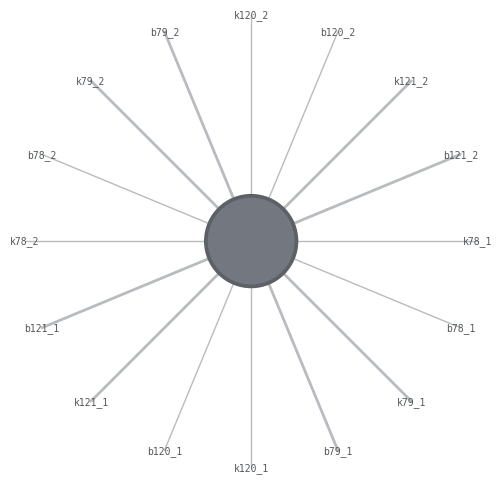

In [94]:
two_sided_environment_matrix.draw()

In [96]:
X = two_sided_environment_matrix.tensors[0].data

In [97]:
np.any(X)

True

Split quatrit sites into qubit sites using multiplexers, demultiplexers.

In [99]:
np_demultiplixer_4_to_2_gate = np.array([
    [
        [1,0,0,0],
        [0,1,0,0],
    ],
    [
        [0,0,1,0],
        [0,0,0,1],
    ]
])

In [100]:
np_multiplixer_2_to_4_gate = np.array([
    [
        [1,0],
        [0,0],
    ],
    [
        [0,1],
        [0,0],
    ],
    [
        [0,0],
        [1,0],
    ],
    [
        [0,0],
        [0,1],
    ]
])

In [101]:
demultiplixer_4_to_2_gate = qtn.Tensor(data=np_demultiplixer_4_to_2_gate, inds=('k1', 'k2', 'b'))
multiplixer_2_to_4_gate = qtn.Tensor(data=np_multiplixer_2_to_4_gate, inds=('b', 'k1', 'k2'))

In [102]:
X = two_sided_environment_matrix.tensors[0].data

In [104]:
# Naming convention:
# k79_1_2 means the first qubit of a d=4 qudit for the second density matrix
# k78_2 means the qubit at site 78 of the second density matrix

qubit_two_sided_environment_matrix = (
    two_sided_environment_matrix
    & demultiplixer_4_to_2_gate.reindex({'b': 'k79_2', 'k1': 'k79_1_2', 'k2': 'k79_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k121_2', 'k1': 'k121_1_2', 'k2': 'k121_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b79_2', 'k1': 'b79_1_2', 'k2': 'b79_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b121_2', 'k1': 'b121_1_2', 'k2': 'b121_2_2'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k79_1', 'k1': 'k79_1_1', 'k2': 'k79_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'k121_1', 'k1': 'k121_1_1', 'k2': 'k121_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b79_1', 'k1': 'b79_1_1', 'k2': 'b79_2_1'})
    & demultiplixer_4_to_2_gate.reindex({'b': 'b121_1', 'k1': 'b121_1_1', 'k2': 'b121_2_1'})
) ^ ...

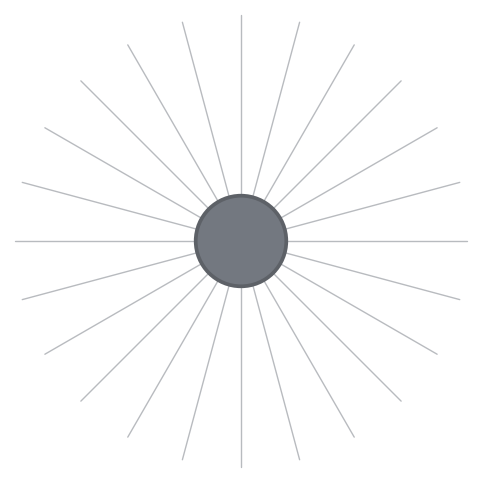

In [105]:
qubit_two_sided_environment_matrix.draw()

In [106]:
qubit_two_sided_environment_matrix

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k78_2', 'b78_2', 'k120_2', 'b120_2', 'k78_1', 'b78_1', 'k120_1', 'b120_1', 'k79_1_2', 'k79_2_2', 'k121_1_2', 'k121_2_2', 'b79_1_2', 'b79_2_2', 'b121_1_2', 'b121_2_2', 'k79_1_1', 'k79_2_1', 'k121_1_1', 'k121_2_1', 'b79_1_1', 'b79_2_1', 'b121_1_1', 'b121_2_1'), tags=oset(['I78', 'I79', 'I80', 'I81', 'I82', 'I83', 'I84', 'I85', 'I86', 'I87', 'I88', 'I89', 'I90', 'I91', 'I92', 'I93', 'I94', 'I95', 'I96', 'I97', 'I98', 'I99', 'I100', 'I101', 'I102', 'I103', 'I104', 'I105', 'I106', 'I107', 'I108', 'I109', 'I110', 'I111', 'I112', 'I113', 'I114', 'I115', 'I116', 'I117', 'I118', 'I119', 'I120', 'I121']))

In [107]:
X = qubit_two_sided_environment_matrix.data

In [108]:
np.sum(X*(X.conj()))

(0.0039062500000001206-1.2704899208484408e-35j)

### Initial boundary operator circuits

In [109]:
def single_qubit_layer(circ, gate_round=None):
    """Apply a parametrizable layer of single qubit ``U3`` gates.
    """
    for i in range(circ.N):
        # initialize with random parameters
        params = qu.randn(3, dist='uniform')
        circ.apply_gate(
            'U3',
            *params,
            i,
            gate_round=gate_round,
            parametrize=True
        )

In [110]:
def two_qubit_layer(circ, gate2='CZ', start=0, gate_round=None):
    """Apply a layer of constant entangling gates.
    """
    num_sites = circ.N

    for i in range(start, start + num_sites - 1):
        circ.apply_gate(
            gate2,
            i,
            i+1,
            gate_round=gate_round
        )

In [111]:
def ansatz_circuit(n, depth, gate2='CZ',
                   gate_tag=None, k_indices=None, b_indices=None, **kwargs):
    """Construct a circuit of single qubit and entangling layers.
    """
    circ = qtn.Circuit(n, **kwargs)

    for r in range(depth):
        # single qubit gate layer
        single_qubit_layer(circ, gate_round=r)

        # alternate between forward and backward CZ layers
        two_qubit_layer(
            circ, gate2=gate2, gate_round=r, start=0
        )

    # add a final single qubit layer
    single_qubit_layer(circ, gate_round=r + 1)

    circ = circ.get_uni(transposed=True)

    if gate_tag is not None:
        for t in circ.tensors:
            t.add_tag(gate_tag)

    if k_indices is not None:
        index_map = {
            f'k{i}': index
            for i, index in zip(range(n), k_indices)
        }
        
        circ.reindex(index_map, inplace=True)

    if b_indices is not None:
        index_map = {
            f'b{i}': index
            for i, index in zip(range(n), b_indices)
        }
        
        circ.reindex(index_map, inplace=True)

    return circ

In [112]:
left_circuit_1 = ansatz_circuit(
    3,
    4,
    k_indices=['k78', 'k79_1', 'k79_2'],
    b_indices=['b78', 'b79_1', 'b79_2']
)

In [113]:
num_sites=3
depth=4

left_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78', 'k79_1', 'k79_2'],
    b_indices=['b78', 'b79_1', 'b79_2'],
    gate_tag='left_1'
)

left_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78', 'k79_1', 'k79_2'],
    b_indices=['b78', 'b79_1', 'b79_2'],
    gate_tag='left_2'
)

right_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120', 'k121_1', 'k121_2'],
    b_indices=['b120', 'b121_1', 'b121_2'],
    gate_tag='right_1'
)

right_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120', 'k121_1', 'k121_2'],
    b_indices=['b120', 'b121_1', 'b121_2'],
    gate_tag='right_2'
)

In [114]:
right_circuit_2

TensorNetworkGenOperator(tensors=31, indices=42)

In [115]:
def partial_tranpose_objective(environment_matrix, left_circuit_1,
    left_circuit_2, right_circuit_1, right_circuit_2):

    rc_1 = (
        right_circuit_1
        .reindex({
            'k120': 'b120_1',
            'k121_1': 'b121_1_1',
            'k121_2': 'b121_2_1',
            'b120': 'k120_2',
            'b121_1': 'k121_1_2',
            'b121_2': 'k121_2_2',
        })
    )
    
    rc_2 = (
        right_circuit_2
        .reindex({
            'k120': 'k120_1',
            'k121_1': 'k121_1_1',
            'k121_2': 'k121_2_1',
            'b120': 'b120_2',
            'b121_1': 'b121_1_2',
            'b121_2': 'b121_2_2',
        })
    )

    lc_1 = (
        left_circuit_1
        .reindex({
            'k78': 'b78_1',
            'k79_1': 'b79_1_1',
            'k79_2': 'b79_2_1',
            'b78': 'k78_2',
            'b79_1': 'k79_1_2',
            'b79_2': 'k79_2_2',
        })
    )
    
    lc_2 = (
        left_circuit_2
        .reindex({
            'k78': 'k78_1',
            'k79_1': 'k79_1_1',
            'k79_2': 'k79_2_1',
            'b78': 'b78_2',
            'b79_1': 'b79_1_2',
            'b79_2': 'b79_2_2',
        })
    )

    a = (
        environment_matrix
        & rc_1
        & rc_2
        & lc_1
        & lc_2
    )

    return a

In [116]:
test = partial_tranpose_objective(
    qubit_two_sided_environment_matrix,
    left_circuit_1,
    left_circuit_2,
    right_circuit_1,
    right_circuit_2
)

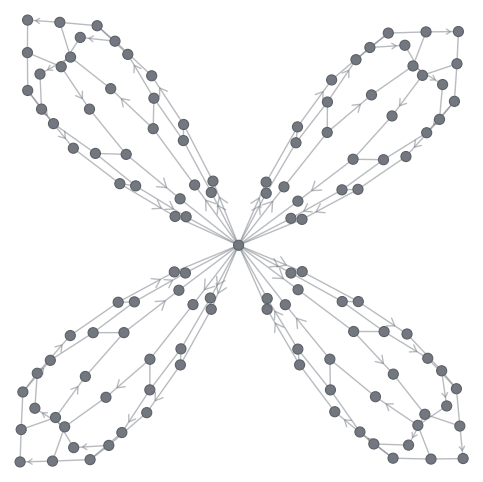

In [117]:
test.draw()

In [118]:
test

TensorNetwork(tensors=125, indices=168)

In [119]:
test^...

(0.0004532288459296256+0.00044296077359199526j)

### Loss function

In [120]:
num_sites=3
depth=1

left_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78_1', 'k79_1_1', 'k79_2_1'],
    b_indices=['b78_1', 'b79_1_1', 'b79_2_1'],
    gate_tag='left_1'
)

left_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78_2', 'k79_1_2', 'k79_2_2'],
    b_indices=['b78_2', 'b79_1_2', 'b79_2_2'],
    gate_tag='left_2'
)

right_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120_1', 'k121_1_1', 'k121_2_1'],
    b_indices=['b120_1', 'b121_1_1', 'b121_2_1'],
    gate_tag='right_1'
)

right_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120_2', 'k121_1_2', 'k121_2_2'],
    b_indices=['b120_2', 'b121_1_2', 'b121_2_2'],
    gate_tag='right_2'
)

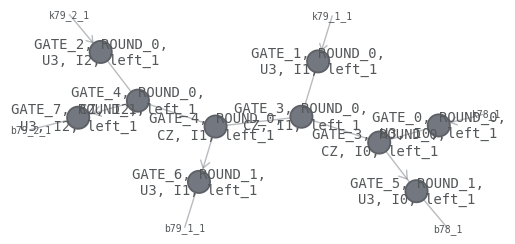

In [121]:
left_circuit_1.draw()

In [122]:
circuits = (
    left_circuit_1
    & left_circuit_2
    & right_circuit_1
    & right_circuit_2
)

In [123]:
def get_sub_circuit(full_circuit, sub_circuit_tag):
    sub_circuit = qtn.TensorNetwork(
        list(map(
            full_circuit.tensor_map.__getitem__,
            full_circuit.tag_map[sub_circuit_tag]
        ))
    )

    return sub_circuit

In [124]:
def split_full_circuit(full_circuit, sub_circuit_tags):
    # Maybe needs to be a dictionary?
    sub_circuits = [
        get_sub_circuit(full_circuit, tag)
        for tag in sub_circuit_tags
    ]

    return sub_circuits

In [125]:
rc_1 = (
    right_circuit_1
    .reindex({
        'k120_1': 'b120_1',
        'k121_1_1': 'b121_1_1',
        'k121_2_1': 'b121_2_1',
        'b120_1': 'k120_2',
        'b121_1_1': 'k121_1_2',
        'b121_2_1': 'k121_2_2',
    })
)

rc_2 = (
    right_circuit_2
    .reindex({
        'k120_2': 'k120_1',
        'k121_1_2': 'k121_1_1',
        'k121_2_2': 'k121_2_1',
        'b120_2': 'b120_2',
        'b121_1_2': 'b121_1_2',
        'b121_2_2': 'b121_2_2',
    })
)

lc_1 = (
    left_circuit_1
    .reindex({
        'k78_1': 'b78_1',
        'k79_1_1': 'b79_1_1',
        'k79_2_1': 'b79_2_1',
        'b78_1': 'k78_2',
        'b79_1_1': 'k79_1_2',
        'b79_2_1': 'k79_2_2',
    })
)

lc_2 = (
    left_circuit_2
    .reindex({
        'k78_2': 'k78_1',
        'k79_1_2': 'k79_1_1',
        'k79_2_2': 'k79_2_1',
        'b78_2_2': 'b78_2',
        'b79_1_2': 'b79_1_2',
        'b79_2_2': 'b79_2_2',
    })
)

a = (
    qubit_two_sided_environment_matrix
    & rc_1
    & rc_2
    & lc_1
    & lc_2
)

In [126]:
a

TensorNetwork(tensors=41, indices=60)

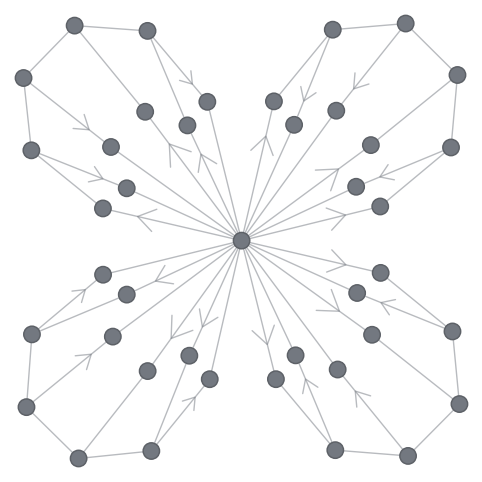

In [127]:
a.draw()

In [128]:
X = qubit_two_sided_environment_matrix.data

In [129]:
np.sum(X*(X.conj()))

(0.0039062500000001206-1.2704899208484408e-35j)

In [130]:
qubit_two_sided_environment_matrix.size

16777216

In [131]:
type(qubit_two_sided_environment_matrix)

quimb.tensor.tensor_core.Tensor

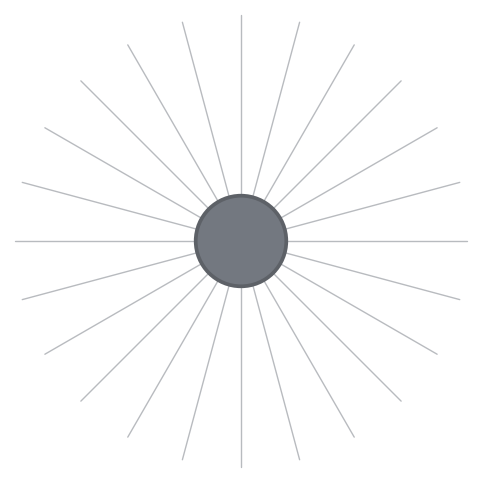

In [132]:
qubit_two_sided_environment_matrix.draw()

In [133]:
def partial_tranpose_objective(environment_matrix, left_circuit_1,
    left_circuit_2, right_circuit_1, right_circuit_2):

    rc_1 = (
        right_circuit_1
        .reindex({
            'k120_1': 'b120_1',
            'k121_1_1': 'b121_1_1',
            'k121_2_1': 'b121_2_1',
            'b120_1': 'k120_2',
            'b121_1_1': 'k121_1_2',
            'b121_2_1': 'k121_2_2',
        })
    )
    
    rc_2 = (
        right_circuit_2
        .reindex({
            'k120_2': 'k120_1',
            'k121_1_2': 'k121_1_1',
            'k121_2_2': 'k121_2_1',
            'b120_2': 'b120_2',
            'b121_1_2': 'b121_1_2',
            'b121_2_2': 'b121_2_2',
        })
    )

    lc_1 = (
        left_circuit_1
        .reindex({
            'k78_1': 'b78_1',
            'k79_1_1': 'b79_1_1',
            'k79_2_1': 'b79_2_1',
            'b78_1': 'k78_2',
            'b79_1_1': 'k79_1_2',
            'b79_2_1': 'k79_2_2',
        })
    )
    
    lc_2 = (
        left_circuit_2
        .reindex({
            'k78_2': 'k78_1',
            'k79_1_2': 'k79_1_1',
            'k79_2_2': 'k79_2_1',
            'b78_2_2': 'b78_2',
            'b79_1_2': 'b79_1_2',
            'b79_2_2': 'b79_2_2',
        })
    )

    a = (
        environment_matrix
        & rc_1
        & rc_2
        & lc_1
        & lc_2
    )

    return a

In [134]:
sub_circuit_tags = [
    'left_1',
    'left_2',
    'right_1',
    'right_2'
]

In [135]:
def loss(full_circuit, environment_tensor_network, sub_circuit_tags):
    sub_circuits = [
        full_circuit.select(tag)
        for tag in sub_circuit_tags
    ]

    contraction = partial_tranpose_objective(
        environment_tensor_network,
        *sub_circuits
    )

    a = contraction ^ ...

    return -jnp.real((a*(a.conj())))

In [136]:
loss(
    circuits,
    environment_tensor_network=qubit_two_sided_environment_matrix,
    sub_circuit_tags=sub_circuit_tags,
)

Array(-8.076374e-08, dtype=float32)

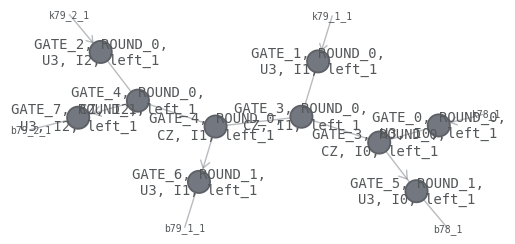

In [137]:
left_circuit_1.draw()

### Optimize

In [140]:
tnopt = qtn.TNOptimizer(
    circuits,  # the tensor network we want to optimize
    loss,  # the function we want to minimize
    loss_constants={
        'environment_tensor_network': qubit_two_sided_environment_matrix
    },
    loss_kwargs={
        'sub_circuit_tags': sub_circuit_tags
    },
    tags=["U3"],  # only optimize U3 tensors
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [142]:
circuits_opt = tnopt.optimize_basinhopping(
    n=500,
    nhop=5,
    jac=True,
    hessp=False,
    ftol=1e-60,
    gtol=1e-60
)

-0.003906226018 [best: -0.003906249534] :  14%|██████                                       | 339/2500 [01:00<06:28,  5.56it/s]


In [145]:
tnopt = qtn.TNOptimizer(
    circuits,  # the tensor network we want to optimize
    loss,  # the function we want to minimize
    loss_constants={
        'environment_tensor_network': qubit_two_sided_environment_matrix
    },
    loss_kwargs={
        'sub_circuit_tags': sub_circuit_tags
    },
    tags=["U3"],  # only optimize U3 tensors
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="adam",  # the optimization algorithm
)

In [147]:
circuits_opt = tnopt.optimize_basinhopping(
    n=2000,
    nhop=5,
    jac=True,
    hessp=False,
    ftol=1e-60,
    gtol=1e-60
)

-0.003906248370 [best: -0.003906251863] : : 12006it [3:18:05,  1.01it/s]                                                       


In [148]:
tnopt = qtn.TNOptimizer(
    circuits,  # the tensor network we want to optimize
    loss,  # the function we want to minimize
    loss_constants={
        'environment_tensor_network': qubit_two_sided_environment_matrix
    },
    loss_kwargs={
        'sub_circuit_tags': sub_circuit_tags
    },
    tags=["U3"],  # only optimize U3 tensors
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [149]:
circuits_opt = tnopt.optimize_basinhopping(
    n=500,
    nhop=5,
    jac=True,
    hessp=False,
    ftol=1e-60,
    gtol=1e-60
)

-0.003906250000 [best: -0.003906250931] :  14%|██████▍                                      | 356/2500 [01:14<07:27,  4.79it/s]


Increase depth

In [154]:
num_sites=3
depth=4

left_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78_1', 'k79_1_1', 'k79_2_1'],
    b_indices=['b78_1', 'b79_1_1', 'b79_2_1'],
    gate_tag='left_1'
)

left_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k78_2', 'k79_1_2', 'k79_2_2'],
    b_indices=['b78_2', 'b79_1_2', 'b79_2_2'],
    gate_tag='left_2'
)

right_circuit_1 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120_1', 'k121_1_1', 'k121_2_1'],
    b_indices=['b120_1', 'b121_1_1', 'b121_2_1'],
    gate_tag='right_1'
)

right_circuit_2 = ansatz_circuit(
    num_sites,
    depth,
    k_indices=['k120_2', 'k121_1_2', 'k121_2_2'],
    b_indices=['b120_2', 'b121_1_2', 'b121_2_2'],
    gate_tag='right_2'
)

circuits = (
    left_circuit_1
    & left_circuit_2
    & right_circuit_1
    & right_circuit_2
)

In [155]:
tnopt = qtn.TNOptimizer(
    circuits,  # the tensor network we want to optimize
    loss,  # the function we want to minimize
    loss_constants={
        'environment_tensor_network': qubit_two_sided_environment_matrix
    },
    loss_kwargs={
        'sub_circuit_tags': sub_circuit_tags
    },
    tags=["U3"],  # only optimize U3 tensors
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [156]:
circuits_opt = tnopt.optimize_basinhopping(
    n=500,
    nhop=5,
    jac=True,
    hessp=False,
    ftol=1e-60,
    gtol=1e-60
)

  0%|                                                                                                 | 0/2500 [00:00<?, ?it/s]/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from float32 to float64.
  warnings.warn(
-0.003906223923 [best: -0.003906244412] :  23%|██████████▏                                  | 569/2500 [09:06<30:53,  1.04it/s]


## Optimize over multiple cases

### Construct environment matrices

In [159]:
x4_gates = [
    qtn.Tensor(data=np.identity(4), inds=('b', 'k')),
    qtn.Tensor(data=np_X4, inds=('b', 'k')),
    qtn.Tensor(data=np_X4@np_X4, inds=('b', 'k')),
    qtn.Tensor(data=np_X4@np_X4@np_X4, inds=('b', 'k'))
]

In [170]:
group_pairs = list(combinations_with_replacement(list(range(4)), 2))

In [172]:
environment_matrices = dict()

for g1, g2 in tqdm(group_pairs):
    x_gates_b = list()
    x_gates_k = list()

    for i in symmetry_sites:
        if (i%2) == 0:
            x2_gate_k = (
                x2_gate
                .copy()
                .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
                .conj()
            )
            x_gates_k.append(x2_gate_k)
    
            x2_gate_b = (
                x2_gate
                .copy()
                .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
                .conj()
            )
            x_gates_b.append(x2_gate_b)
        else:
            x4_gate_k = (
                x4_gates[g1]
                .copy()
                .reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
                .conj()
            )
            x_gates_k.append(x4_gate_k)
    
            x4_gate_b = (
                x4_gates[g2]
                .copy()
                .reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
                .conj()
            )
            x_gates_b.append(x4_gate_b)

    two_sided_environment_matrix = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )
    two_sided_environment_matrix.contract(inplace=True)
    qubit_two_sided_environment_matrix = (
        two_sided_environment_matrix
        & demultiplixer_4_to_2_gate.reindex({'b': 'k79_2', 'k1': 'k79_1_2', 'k2': 'k79_2_2'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'k121_2', 'k1': 'k121_1_2', 'k2': 'k121_2_2'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'b79_2', 'k1': 'b79_1_2', 'k2': 'b79_2_2'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'b121_2', 'k1': 'b121_1_2', 'k2': 'b121_2_2'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'k79_1', 'k1': 'k79_1_1', 'k2': 'k79_2_1'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'k121_1', 'k1': 'k121_1_1', 'k2': 'k121_2_1'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'b79_1', 'k1': 'b79_1_1', 'k2': 'b79_2_1'})
        & demultiplixer_4_to_2_gate.reindex({'b': 'b121_1', 'k1': 'b121_1_1', 'k2': 'b121_2_1'})
    ) ^ ...
    environment_matrices[(g1, g2)] = qubit_two_sided_environment_matrix

100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:12<00:00, 43.26s/it]


### Construct ansatz circuits

In [184]:
num_sites=3
depth=2

circuit_list = list()

for g in range(4):
    left_circuit = ansatz_circuit(
        num_sites,
        depth,
        k_indices=[f'k78_{g}', f'k79_1_{g}', f'k79_2_{g}'],
        b_indices=[f'b78_{g}', f'b79_1_{g}', f'b79_2_{g}'],
        gate_tag=f'left_{g}'
    )

    right_circuit = ansatz_circuit(
        num_sites,
        depth,
        k_indices=[f'k120_{g}', f'k121_1_{g}', f'k121_2_{g}'],
        b_indices=[f'b120_{g}', f'b121_1_{g}', f'b121_2_{g}'],
        gate_tag=f'right_{g}'
    )

    circuit_list.append((left_circuit, right_circuit))

In [185]:
circuits_tn = qtn.TensorNetwork([x for l in circuit_list for x in l])

### Evaluate full tensor
First for a pair

In [220]:
def partial_transpose_sub_objective(environment_matrices, circuit_tn, g1, g2):
    environment_matrix = environment_matrices[(g1, g2)]

    left_circuit_1 = circuit_tn.select(f'left_{g1}')
    right_circuit_1 = circuit_tn.select(f'right_{g1}')
    left_circuit_2 = circuit_tn.select(f'left_{g2}')
    right_circuit_2 = circuit_tn.select(f'right_{g2}')

    rc_1 = (
        right_circuit_1
        .reindex({
            f'k120_{g1}': 'b120_1',
            f'k121_1_{g1}': 'b121_1_1',
            f'k121_2_{g1}': 'b121_2_1',
            f'b120_{g1}': 'k120_2',
            f'b121_1_{g1}': 'k121_1_2',
            f'b121_2_{g1}': 'k121_2_2',
        })
    )
    
    rc_2 = (
        right_circuit_2
        .reindex({
            f'k120_{g2}': 'k120_1',
            f'k121_1_{g2}': 'k121_1_1',
            f'k121_2_{g2}': 'k121_2_1',
            f'b120_{g2}': 'b120_2',
            f'b121_1_{g2}': 'b121_1_2',
            f'b121_2_{g2}': 'b121_2_2',
        })
    )

    lc_1 = (
        left_circuit_1
        .reindex({
            f'k78_{g1}': 'b78_1',
            f'k79_1_{g1}': 'b79_1_1',
            f'k79_2_{g1}': 'b79_2_1',
            f'b78_{g1}': 'k78_2',
            f'b79_1_{g1}': 'k79_1_2',
            f'b79_2_{g1}': 'k79_2_2',
        })
    )
    
    lc_2 = (
        left_circuit_2
        .reindex({
            f'k78_{g2}': 'k78_1',
            f'k79_1_{g2}': 'k79_1_1',
            f'k79_2_{g2}': 'k79_2_1',
            f'b78_{g2}': 'b78_2',
            f'b79_1_{g2}': 'b79_1_2',
            f'b79_2_{g2}': 'b79_2_2',
        })
    )

    a = (
        environment_matrix
        & rc_1
        & rc_2
        & lc_1
        & lc_2
    ) ^ ...

    return a

In [233]:
len(group_pairs)

10

In [229]:
def partial_transpose_full_objective(circuit_tn, environment_matrices):
    out = sum(
        -jnp.abs(partial_transpose_sub_objective(
            environment_matrices,
            circuit_tn,
            g1,
            g2
        ))**2
        for g1, g2 in group_pairs
    )

    return out

In [225]:
partial_transpose_sub_objective(
    environment_matrices,
    circuits_tn,
    0,
    1
)

(3.1202009527321745e-05+5.052591919902944e-05j)

In [226]:
partial_transpose_full_objective(environment_matrices, circuits_tn)

Array(-5.189119e-07, dtype=float32)

In [236]:
len(environment_matrices)

10

In [239]:
for mat in environment_matrices.values():
    X = mat.data
    print(np.sum(X*(X.conj())))

(0.003906250000000127-9.189246841764923e-36j)
(0.003906250000000116+1.5327165131440564e-36j)
(0.003906250000000126-5.759723596896358e-37j)
(0.003906250000000112-7.30239758186824e-36j)
(0.003906250000000089-3.9845860631118834e-36j)
(0.0039062500000001206-1.2704899208484408e-35j)
(0.00390625000000009-7.277716196652196e-36j)
(0.003906250000000126+8.795115915190879e-36j)
(0.003906250000000112-5.0325827215552324e-36j)
(0.003906250000000089-1.0914513899921656e-36j)


### Optimize

In [230]:
tnopt = qtn.TNOptimizer(
    circuits_tn,  # the tensor network we want to optimize
    partial_transpose_full_objective,  # the function we want to minimize
    loss_constants={
        'environment_matrices': environment_matrices
    },
    tags=["U3"],  # only optimize U3 tensors
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [232]:
circuits_opt = tnopt.optimize_basinhopping(
    n=100,
    nhop=5,
    jac=True,
    hessp=False,
    ftol=1e-60,
    gtol=1e-60
)

-0.027343621477 [best: -0.027343723923] :  12%|█████▌                                         | 59/500 [04:45<35:36,  4.84s/it]


In [235]:
256*(0.027343723923)

6.999993324288